 GENERATING INSTITUTIONAL PORTFOLIO TEARSHEET 
Total Stitched PnL:            $20,108.90
Portfolio Profit Factor:       1.24
Portfolio Win Rate:            29.21%
Max Peak-to-Trough Drawdown:   $-3,610.50
Annualized Sharpe Ratio:       2.58
Annualized Sortino Ratio:      6.03
Calmar Ratio:                  7.31
Total Portfolio Executions:    1732 trades


/tmp/ipykernel_2595/4209200373.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


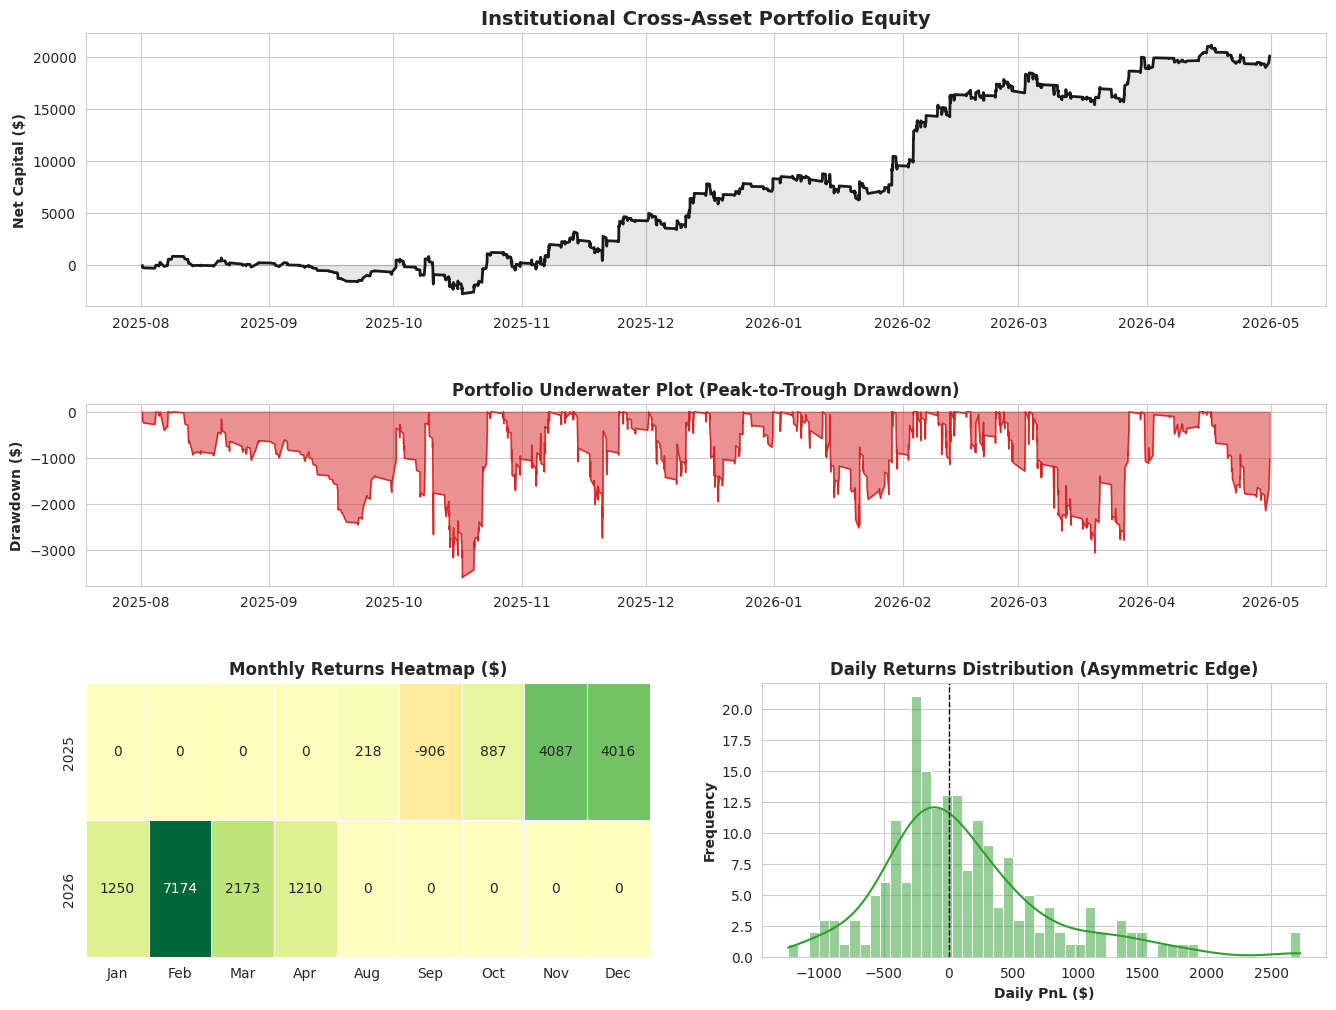

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import calendar

print("=" * 60)
print(" GENERATING INSTITUTIONAL PORTFOLIO TEARSHEET ")
print("=" * 60)

# 1. Ingest Data
csv_files = glob.glob("*.csv")
if not csv_files:
    csv_files = glob.glob("/content/*.csv")
if not csv_files:
    raise FileNotFoundError("No CSV files found. Please upload all trade logs.")

def clean_currency(series):
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)
    cleaned = (series.astype(str).str.replace('$', '', regex=False)
               .str.replace(',', '', regex=False).str.replace('(', '-', regex=False)
               .str.replace(')', '', regex=False).str.strip())
    return pd.to_numeric(cleaned, errors='coerce').fillna(0.0)

processed_dfs = []
for file in csv_files:
    temp_df = pd.read_csv(file)
    temp_df.columns = [c.strip() for c in temp_df.columns]
    date_col = next((col for col in ['Exit time', 'Exit Time', 'Date', 'Time', 'Timestamp'] if col in temp_df.columns), None)
    pnl_col = next((col for col in ['Profit', 'Net profit', 'Net Profit', 'Profit ($)', 'Cum. profit', 'Net_PnL'] if col in temp_df.columns), None)

    if date_col and pnl_col:
        temp_df['Date'] = pd.to_datetime(temp_df[date_col], errors='coerce', dayfirst=True)
        temp_df['Net_PnL'] = clean_currency(temp_df[pnl_col])
        processed_dfs.append(temp_df[['Date', 'Net_PnL']].dropna())

master_df = pd.concat(processed_dfs, ignore_index=True).sort_values('Date').reset_index(drop=True)

# 2. Core Math & Risk Metrics
master_df['Cumulative_Equity'] = master_df['Net_PnL'].cumsum()
master_df['Peak'] = master_df['Cumulative_Equity'].cummax()
master_df['Drawdown'] = master_df['Cumulative_Equity'] - master_df['Peak']
max_dd = master_df['Drawdown'].min()

total_profit = master_df['Net_PnL'].sum()
wins = master_df[master_df['Net_PnL'] > 0]['Net_PnL']
losses = master_df[master_df['Net_PnL'] < 0]['Net_PnL']
win_rate = (len(wins) / len(master_df)) * 100 if len(master_df) > 0 else 0
pf = wins.sum() / abs(losses.sum()) if losses.sum() != 0 else np.inf

# Daily Aggregation for Advanced Metrics
daily_returns = master_df.groupby(master_df['Date'].dt.date)['Net_PnL'].sum()
mean_daily = daily_returns.mean()
std_daily = daily_returns.std()
downside_std = daily_returns[daily_returns < 0].std()

sharpe = (mean_daily / std_daily) * np.sqrt(252) if len(daily_returns) > 1 and std_daily != 0 else 0
sortino = (mean_daily / downside_std) * np.sqrt(252) if len(daily_returns) > 1 and downside_std != 0 else 0
annualized_return = mean_daily * 252
calmar = abs(annualized_return / max_dd) if max_dd != 0 else 0

print(f"Total Stitched PnL:            ${total_profit:,.2f}")
print(f"Portfolio Profit Factor:       {pf:.2f}")
print(f"Portfolio Win Rate:            {win_rate:.2f}%")
print(f"Max Peak-to-Trough Drawdown:   ${max_dd:,.2f}")
print(f"Annualized Sharpe Ratio:       {sharpe:.2f}")
print(f"Annualized Sortino Ratio:      {sortino:.2f}")
print(f"Calmar Ratio:                  {calmar:.2f}")
print(f"Total Portfolio Executions:    {len(master_df)} trades")
print("=" * 60)

# 3. Monthly Heatmap Data Prep
master_df['YearMonth'] = master_df['Date'].dt.to_period('M')
monthly_pnl = master_df.groupby('YearMonth')['Net_PnL'].sum().reset_index()
monthly_pnl['Year'] = monthly_pnl['YearMonth'].dt.year
monthly_pnl['Month'] = monthly_pnl['YearMonth'].dt.month
heatmap_data = monthly_pnl.pivot(index='Year', columns='Month', values='Net_PnL').fillna(0)
heatmap_data.columns = [calendar.month_abbr[m] for m in heatmap_data.columns]

# 4. Institutional 4-Panel Visualization
sns.set_style("whitegrid")
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1.5, 1, 1.5], hspace=0.4, wspace=0.2)

# Panel 1: Master Equity Curve (Spans top row)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(master_df['Date'], master_df['Cumulative_Equity'], color='#1a1a1a', linewidth=2)
ax1.fill_between(master_df['Date'], master_df['Cumulative_Equity'], 0, color='#1a1a1a', alpha=0.1)
ax1.set_title('Institutional Cross-Asset Portfolio Equity', fontsize=14, fontweight='bold')
ax1.set_ylabel('Net Capital ($)', fontweight='bold')

# Panel 2: Underwater Plot (Drawdown) (Spans middle row)
ax2 = fig.add_subplot(gs[1, :], sharex=ax1)
ax2.fill_between(master_df['Date'], master_df['Drawdown'], 0, color='#d62728', alpha=0.5)
ax2.plot(master_df['Date'], master_df['Drawdown'], color='#d62728', linewidth=1)
ax2.set_title('Portfolio Underwater Plot (Peak-to-Trough Drawdown)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Drawdown ($)', fontweight='bold')

# Panel 3: Monthly Returns Heatmap (Bottom left)
ax3 = fig.add_subplot(gs[2, 0])
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="RdYlGn", center=0, ax=ax3, cbar=False, linewidths=.5)
ax3.set_title('Monthly Returns Heatmap ($)', fontsize=12, fontweight='bold')
ax3.set_ylabel('')

# Panel 4: Daily Returns Distribution (Bottom right)
ax4 = fig.add_subplot(gs[2, 1])
sns.histplot(daily_returns, bins=50, kde=True, color='#2ca02c', ax=ax4)
ax4.axvline(0, color='black', linestyle='--', linewidth=1)
ax4.set_title('Daily Returns Distribution (Asymmetric Edge)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Daily PnL ($)', fontweight='bold')
ax4.set_ylabel('Frequency', fontweight='bold')

plt.tight_layout()
plt.show()